# Swarm Intelligence Workbook

In [1]:
import numpy as np

This tutorial explains canonical two particle swarm optimisation (PSO) algorithms, namely `gbest` and `lbest`. Implementations are made with reference to _Fundamentals of Computational Swarm Intelligence_ by Engelbrecht and Andries.

To begin, let's set up some parameters and types:

In [2]:
N: int = 100 # Number of particles
D: int = 2 # Size of each particle
T: int = 60 # Number of iterations
from typing import Literal

type Swarm =\
        np.ndarray[tuple[Literal['N'],
                         Literal['D']],
                   np.dtype[np.int32]]

type Particle =\
        np.ndarray[tuple[Literal['D']],
                   np.dtype[np.int32]]

In very broad strokes, a PSO algorithm maintains a swarm of "particles". Given the problem, each particle represents a solution in an abstract space. The algorithm optimises by moving these particles around, hoping that one finds a solution that better solves the problem.

### Define the Swarm

Define variable `X` that represents the swarm. `X` is a $N\times D$ matrix, where `X[]n]` is the $n^{\mathrm{th}}$ particle and `X[n][d]` is the $d^{\mathrm{th}}$ item in that particle. Define `Y` to store "personal bests", such that `Y[n]` is the personal best of `X[n]`.

Also, define variable `X_T` that records the history of `X`. Each `X_T[t]` should be `X` at time step `t`. Similarly, define `Y_T` for `Y`.

In [3]:
from typing import Callable, Any

# The domain of Any, Any is hard-coded according
#   to D=2.
INITIALISER: Callable[[int, int], float] =\
    lambda _1, _2: np.random.uniform(low = -10, high= -8)

X: Swarm = np.fromfunction(np.vectorize(INITIALISER),
                           shape=(N, D),
                           dtype=float)
Y: Swarm = np.copy(X)

V: Swarm = np.zeros(shape=(N, D),
                    dtype=float)

X_T: list[Swarm] = []
Y_T: list[Swarm] = []

### Problem and Measure of Success

Define the **objective function** `OBJECTIVE` to capture the problem. Also define `is_better_than`, a way to compare two **fitnesses**. The fitness describes how well the solution solves the problem.

The artificial life / evolutionary computing community tends to model with maximisation problems. This choice is arbitrary.

In [4]:
import ograph.ofunc as ofunc

OBJECTIVE: Callable[[Particle],
                    float] =\
    lambda x: -ofunc.rosenbrock(*x)

is_better_than: Callable[[float, float],
                         bool] =\
    lambda x, y: x > y

### Define the Algorithm

here you go.

In [5]:
# Initialising y_hat to X[0] is arbitrary.
# Would be typely-correct to use `Optional`, but one
#   can't be correct all the time.
y_hat: Particle = X[0]
fy_hat: float = OBJECTIVE(y_hat)
y_hat_T: list[Particle] = []
fy_hat_T: list[float] = []

assert X.shape == (N, D)
assert Y.shape == (N, D)
assert V.shape == (N, D)

C_1: float = 1
C_2: float = 1

for _ in range(T):
    # For each iteration:
    # For each particle in swarm:
    for i in range(N):
        fy_i = OBJECTIVE(Y[i])
        fx_i = OBJECTIVE(X[i])

        if is_better_than(fx_i,
                          fy_i):
            Y[i] = X[i]
            fy_i = fx_i

        if is_better_than(fy_i,
                          fy_hat):
            y_hat = Y[i]
            fy_hat = fy_i
    
    for i in range(N):
        for j in range(len(V[i])):
            r_1j: float = np.random.uniform(0, 1)
            r_2j: float = np.random.uniform(0, 1)
            V[i][j] = V[i][j] +\
                C_1 * r_1j * (Y[i][j]-X[i][j]) +\
                C_2 * r_2j * (y_hat[j]-X[i][j])
            
        X[i] = X[i] + V[i]


    X_T.append(X.copy())
    Y_T.append(Y.copy())
    y_hat_T.append(y_hat)
    fy_hat_T.append(fy_hat)

## Visualisation

OPlot provides a comprehensive set of tools to visualise 

## Plot Past Solutions

Plot past values of `X`. Recall that `X_T[t]` is `X[t]` at time `t`.

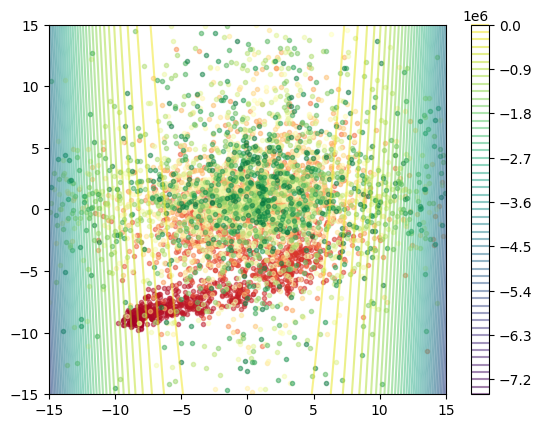

In [6]:
from ograph.swarm import plot_positions, plot_fitnesses


mort = np.array(X_T)
plot_positions(mort[:,:,:],
               lambda x, y: OBJECTIVE((x, y)),
               override_region=((-15, 15), (-15, 15)))

### Plot Past Fitnesses

Plot past values of $f(\hat{y})$.

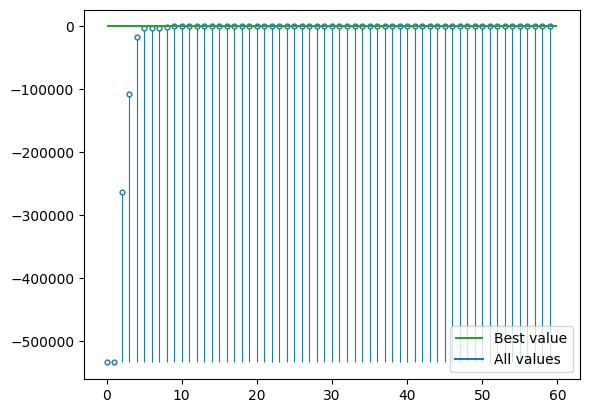

In [7]:
plot_fitnesses(fy_hat_T)

Prepare types of arrays and matrices.

In [8]:
from typing import TypeAlias

ArrayND: TypeAlias = np.ndarray[tuple[Any, ...],
                                np.dtype[np.float64]]

### Plot Other Metrics

#### Diameter

In [9]:
from typing import Optional
import numpy as np
from scipy.spatial import ConvexHull
from scipy.spatial.distance import cdist

def diameter(data: ArrayND,
             metric: Optional[str
                              | Callable[[ArrayND, ArrayND], np.float64]] = 'euclidean')\
                -> np.float64:
    """Compute the diameter of :arg:`data` according
    to the :arg:`distance` measure. Returns two points that produce
    this diameter.

    The diameter of a set of points is the maximum
    distance between any two points in the set.

    Args:
        data: A collection of points, where :code:`data[i]`
            is the ith point. 

        distance: A measure of distance. Defaults to
            the L-2 norm. Given to :meth:`scipy.spatial.distance.cdist`.
    """

    chull: ArrayND = data[ConvexHull(data).vertices]
    
    dists: ArrayND = cdist(chull, chull, metric=metric) # type: ignore

    # Fix this
    return dists.max()

#### Potential Energy



In [10]:
from typing import Sequence
from ograph.oplot import Vec1D, Vec2D, Vec3D

Define the potential energy of the swarm:

$$E_p(X)=\sum^{N}_{i=1}{e_{i}[t]}$$

$$e_n[t]=\frac{|f(\mathrm{x}[t])-\mathrm{x}^*|}{\epsilon}$$

In [11]:
def potential_energy(X: Swarm, ideal, epsilon):
    return np.sum([np.abs(OBJECTIVE(x) - ideal) / epsilon for x in X])

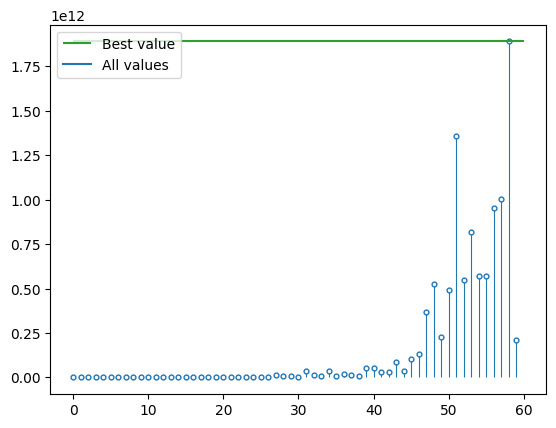

In [12]:
plot_fitnesses([potential_energy(X, ideal=0, epsilon=0.1) for X in X_T])

#### Reliability

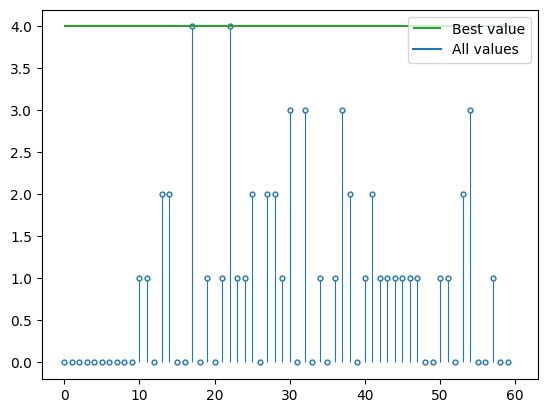

In [13]:
def reliability(X: Vec3D, ideal, epsilon):
    return np.sum([1 for x in X if np.abs(OBJECTIVE(x) - ideal) < epsilon])
plot_fitnesses([reliability(X, ideal=0, epsilon=4) for X in X_T])

#### Diversity

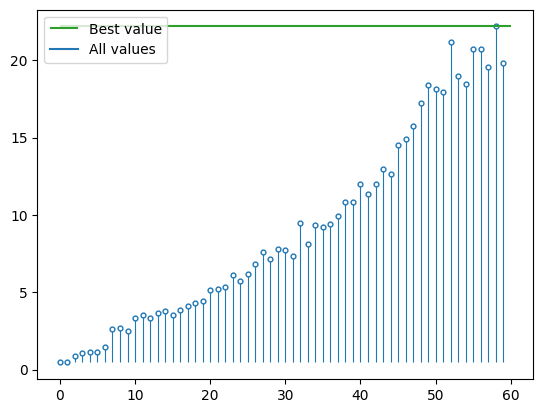

In [15]:
def diversity(X):
    _summand_n = 0
    for n in range(X.shape[0]):
        bucephalus = X.mean(axis=0)
        _summand_d = 0
        for d in range(X.shape[1]):
            _summand_d += (X[n][d] - bucephalus[d]) ** 2
        _summand_n += np.sqrt(_summand_d)
    return _summand_n / X.shape[0]
plot_fitnesses([diversity(X) for X in X_T])

In [16]:
def reliability(X: Vec3D, ideal, epsilon):
    return np.sum([x for x in X if np.abs(OBJECTIVE(x) - ideal) > epsilon])

In [ ]:
# Extract the points forming the hull


# Naive way of finding the best pair in O(H^2) time if H is number of points on
# hull
hdist = cdist(hullpoints, hullpoints, metric='euclidean')

# Get the farthest apart points


#Print them
print([hullpoints[bestpair[0]],hullpoints[bestpair[1]]])

NameError: name 'hullpoints' is not defined

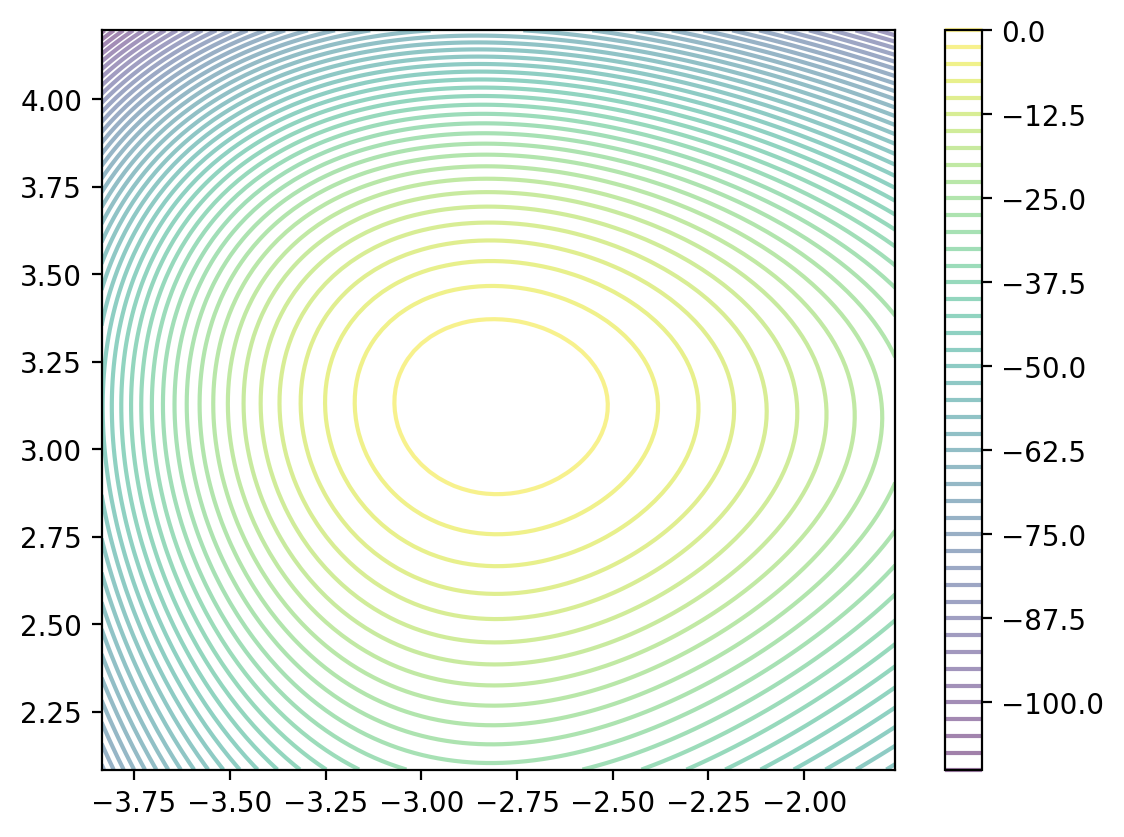

In [ ]:


data = y_hat_T
mort: Sequence[Sequence[float]] = data
assert len(mort[0]) == 2

xs: Sequence[float] = [k[0] for k in mort]
ys: Sequence[float] = [k[1] for k in mort]

x_min = np.min(xs)
x_max = np.max(xs)

y_min = np.min(ys)
y_max = np.max(ys)



oplot.contour(lambda x, y: OBJECTIVE((x, y)), # type: ignore[reportArgumentType]
            x_range=(x_min-1, x_max+1),
            y_range=(y_min-1, y_max+1))


In [ ]:
ConvexHull


In [ ]:
def diameter(, measure: Callable[]) -> float:




In [ ]:
hull.simplices

array([[1079,  484,   32],
       [1412,  469,  518],
       [1412, 1290,  133],
       [1412, 1109, 1290],
       [ 160, 1079, 1271],
       [ 160, 1079,   32],
       [ 160,  484,  518],
       [ 160,  484,   32],
       [1473,  160, 1271],
       [1236,  511,  121],
       [ 810,  121,  674],
       [ 910,  334,  469],
       [ 910, 1412,  133],
       [ 910, 1412,  469],
       [1315,  639,   17],
       [1315,  615,  639],
       [1315,  484,  518],
       [1315,  615,  518],
       [ 751, 1079,  484],
       [ 751, 1315,   17],
       [ 751, 1315,  484],
       [1507,  615,  674],
       [   8,  469,  518],
       [   8,  615,  518],
       [ 427,  160,  518],
       [ 427, 1473, 1109],
       [ 427, 1473,  160],
       [ 826,  821, 1254],
       [ 804,  826, 1238],
       [ 804,  826,  821],
       [ 718,  640,  334],
       [ 718,  895,  218],
       [ 718,  810,  121],
       [ 718,  511,  121],
       [ 718,  895,  511],
       [ 196,  121,  674],
       [ 196, 1448,  674],
 